# import libraries

In [1]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical calculations
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Statistical visualizations
from scipy import stats      # Chi-square, t-test, confidence intervals
import plotly.express as px  # Interactive charts (bonus — very impressive)

# load Data

In [2]:
daily_df = pd.read_csv('SQL expoted tables\compare daily.csv')
kpi_df = pd.read_csv('SQL expoted tables\KPIs.csv')
funnel_df = pd.read_csv('SQL expoted tables\stage conversion funnel.csv')
summary_df = pd.read_csv('SQL expoted tables\summary table.csv')

# part 1 - KPIs

In [ ]:
sns.barplot(x='Campaign_Name' ,y='CTR' ,data =kpi_df)
plt.title('CTR: Control vs. Test Campaign')
plt.xlabel('Campaign Type')
plt.ylabel('CTR %')
plt.savefig('visualizations/CTR.png', bbox_inches='tight')
plt.show()


In [ ]:
sns.barplot(x='Campaign_Name' ,y='CPC' ,data =kpi_df)
plt.title('CPC: Control vs. Test Campaign')
plt.xlabel('Campaign Type')
plt.ylabel('$ per click')
plt.savefig('visualizations/CPC.png', bbox_inches='tight')
plt.show()


In [ ]:
sns.barplot(x='Campaign_Name' ,y='CPA' ,data =kpi_df)
plt.title('CPA: Control vs. Test Campaign')
plt.xlabel('Campaign Type')
plt.ylabel('$ per acquisition')
plt.savefig('visualizations/CPA.png', bbox_inches='tight')
plt.show()


In [ ]:
sns.barplot(x='Campaign_Name' ,y='CPM' ,data =kpi_df)
plt.title('CPM: Control vs. Test Campaign')
plt.xlabel('Campaign Type')
plt.ylabel('$ per 1000 impressions.')
plt.savefig('visualizations/CPM.png', bbox_inches='tight')
plt.show()


# part 2 - funnel conversion and volume

In [ ]:
long_funnel_df = funnel_df.melt(id_vars='Campaign_Name')

In [ ]:
sns.barplot(x='variable' ,y='value' ,hue="Campaign_Name",data =long_funnel_df)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Funnel Stage')
plt.ylabel('Conversion Rate (%)')
plt.savefig('visualizations/funnel conversion.png', bbox_inches='tight')
plt.show()


In [ ]:
long_sum_df = summary_df.melt(id_vars='Campaign_Name')

In [ ]:
sns.barplot(x='variable' ,y='value' ,hue="Campaign_Name",data =long_sum_df[2:])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Funnel Stage')
plt.ylabel('volume')
plt.savefig('visualizations/funnel volume.png', bbox_inches='tight')
plt.show()


# part 4 - Time Series from the Daily Table

In [ ]:
daily_df.head()

In [ ]:
sns.lineplot(x ='Date' ,y='daily_purchase' , hue ='Campaign_Name' ,data = daily_df)
plt.xticks(rotation=45, ha='right')
plt.savefig('visualizations/daily_purchases.png', bbox_inches='tight')
plt.show()

In [ ]:
sns.lineplot(x ='Date' ,y='rolling_daily_spend' , hue ='Campaign_Name' ,data = daily_df)
plt.xticks(rotation=45, ha='right')
plt.savefig('visualizations/daily_rolling_spend.png', bbox_inches='tight')
plt.show()

# part 5 - chi squere test: Control vs Test conversion rates

In [15]:
#Build a contingency table
contingency_df = summary_df[["Campaign_Name","total_purchase"]].copy()
not_purchased = (summary_df["total_Add_to_Cart"] - summary_df["total_purchase"])
contingency_df["not_purchased"] = not_purchased
contingency_df.head()

,Campaign_Name,total_purchase,not_purchased
0,Control Campaign,15161,22539
1,Test Campaign,14869,10621


In [16]:
# the chi test
stats.chi2_contingency(contingency_df[["total_purchase", "not_purchased"]])

Chi2ContingencyResult(statistic=np.float64(2000.9866443595179), pvalue=np.float64(0.0), dof=1, expected_freq=array([[17916.30004748, 19783.69995252],
       [12113.69995252, 13376.30004748]]))

# part 6 - T-Test on Daily Purchases and z test 

In [16]:

daily_purchase_Control = daily_df[daily_df["Campaign_Name"] == "Control Campaign"]["daily_purchase"]
daily_purchase_test = daily_df[daily_df["Campaign_Name"] == "Test Campaign"]["daily_purchase"]


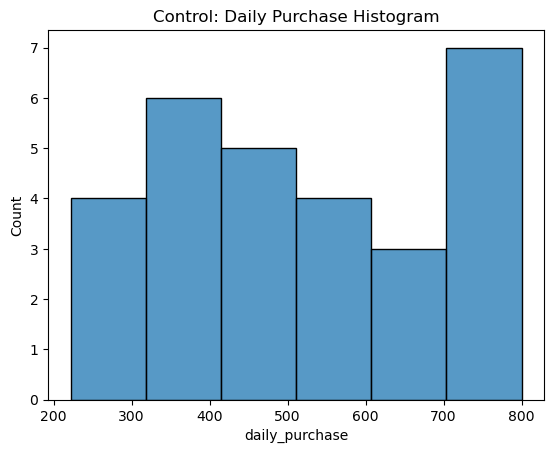

In [17]:
#check for skew in the control group
sns.histplot(data = daily_df[daily_df["Campaign_Name"] == "Control Campaign"], x = "daily_purchase")
plt.title('Control: Daily Purchase Histogram')
plt.show()

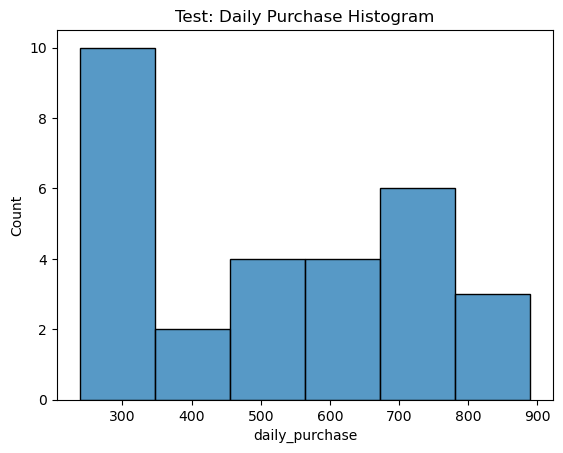

In [18]:
#check for skew in the test group
sns.histplot(data = daily_df[daily_df["Campaign_Name"] == "Test Campaign"], x = "daily_purchase")
plt.title('Test: Daily Purchase Histogram')
plt.show()

In [ ]:
# we don't have a normal distribution so we will use the  Mann-Whitney U test insted of the T-test

In [20]:
stats.mannwhitneyu(daily_purchase_Control,daily_purchase_test)

MannwhitneyuResult(statistic=np.float64(436.0), pvalue=np.float64(0.8155354572265037))

In [6]:
#average daily purchases differ between campaigns, just due to day-to-day noise because pvalue >0.05

# part 7 - heatmap

In [ ]:
original_df = pd.read_csv('SQL expoted tables\original.csv')

In [ ]:
original_mtx = original_df.corr(numeric_only=True)
sns.heatmap(original_mtx, cmap="YlGnBu", annot=True)
plt.savefig('visualizations/plot.png', bbox_inches='tight')
plt.show()